# Regresión Múltiple y Diagnóstico
## Modelado Predictivo en Ecosistemas Marino-Costeros

---

## ¿Qué es la Regresión Múltiple?

La **regresión múltiple (OLS — Mínimos Cuadrados Ordinarios)** modela la relación lineal entre una variable dependiente $Y$ y múltiples variables independientes $X_1, X_2, \ldots, X_p$:

$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \cdots + \beta_p X_p + \varepsilon$$

Donde:
- $\beta_0$: intercepto (valor de Y cuando todas las X = 0)
- $\beta_i$: coeficiente de regresión (cambio en Y por unidad de cambio en $X_i$, manteniendo las demás constantes)
- $\varepsilon \sim N(0, \sigma^2)$: término de error

El método OLS minimiza la **Suma de Cuadrados de los Residuos (RSS)**:
$$RSS = \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

---

## Supuestos de la Regresión Múltiple (Gauss-Markov)

| Supuesto | Descripción | Consecuencia si se viola |
|----------|-------------|--------------------------|
| **Linealidad** | Relación lineal entre Y y las X | Sesgos sistemáticos en predicciones |
| **Independencia de errores** | Sin autocorrelación en los residuos | Subestimación de errores estándar |
| **Homocedasticidad** | Varianza constante de los residuos | Inferencia incorrecta sobre coeficientes |
| **Normalidad de errores** | $\varepsilon \sim N(0, \sigma^2)$ | Tests de hipótesis inválidos |
| **Ausencia de multicolinealidad** | Las X no están fuertemente correlacionadas | Coeficientes inestables e ininterpretables |

---

## Métricas de Evaluación del Modelo

| Métrica | Fórmula | Interpretación |
|---------|---------|----------------|
| **R²** | $1 - RSS/TSS$ | Proporción de varianza explicada (0-100%) |
| **R² ajustado** | Penaliza por número de predictores | Evita sobreajuste con muchas variables |
| **p-valor coeficiente** | Test t: $t = \hat{\beta}/SE(\hat{\beta})$ | Significancia estadística del predictor |
| **VIF** | $VIF_j = 1/(1 - R_j^2)$ | VIF > 10 indica multicolinealidad grave |
| **AIC / BIC** | Criterios de información | Menor = mejor modelo para comparación |

---

## Diagnóstico Visual (4 Gráficos Clave)

1. **Residuos vs Valores Ajustados**: Verifica linealidad y homocedasticidad
2. **Q-Q Plot de Residuos**: Verifica normalidad de los errores
3. **Scale-Location Plot**: Verifica homocedasticidad (raíz de residuos estandarizados)
4. **Residuos vs Leverage**: Identifica observaciones influyentes (Cook's Distance)

---

## Objetivos de Aprendizaje

- Detectar multicolinealidad usando el Factor de Inflación de la Varianza (VIF)
- Ajustar un modelo OLS con statsmodels e interpretar su tabla de resultados
- Realizar los 4 diagnósticos de residuales para verificar supuestos
- Interpretar coeficientes en contexto ecológico marino
- Agregar términos cuadráticos para capturar relaciones no lineales

---

## Aplicaciones Marino-Costeras

- Predecir distancias de migración de peces en función de temperatura, salinidad y corrientes
- Modelar blanqueamiento de coral como función de estrés térmico, pH y turbidez
- Estimar biomasa de algas a partir de luz, nutrientes y temperatura
- Relacionar abundancia de especies con variables de calidad de agua

---

## Duración Estimada
60-90 minutos


## Marco Teórico: Regresión Múltiple en Profundidad

### Coeficientes OLS — Interpretación

Cada coeficiente $\hat{\beta}_j$ representa el **efecto parcial** de $X_j$ sobre $Y$, manteniendo todas las demás variables constantes (*ceteris paribus*):

- Si $\hat{\beta}_{temperatura} = 5.2$: por cada grado Celsius adicional de temperatura, la distancia de migración aumenta 5.2 km, **controlando** salinidad y velocidad de corriente
- El signo indica dirección: positivo = relación directa; negativo = relación inversa

### Tabla de Resultados OLS — statsmodels

```
                 coef    std err          t      P>|t|    [0.025    0.975]
Temperature     5.200      0.180     28.889      0.000     4.847     5.553
Salinity        2.010      0.098     20.510      0.000     1.818     2.202
Current Speed   3.050      0.490      6.224      0.000     2.088     4.012
```

- **coef**: Coeficiente estimado
- **std err**: Error estándar del coeficiente (mayor = más incertidumbre)
- **t**: Estadístico de prueba = coef / std err
- **P>|t|**: p-valor; si < 0.05 → el predictor es estadísticamente significativo
- **[0.025, 0.975]**: Intervalo de confianza al 95% para el coeficiente

### Factor de Inflación de la Varianza (VIF)

$$VIF_j = \frac{1}{1 - R_j^2}$$

Donde $R_j^2$ es el R² de la regresión de $X_j$ sobre todas las demás variables.

| VIF | Interpretación |
|-----|----------------|
| 1 | Sin multicolinealidad |
| 1-5 | Multicolinealidad moderada, generalmente aceptable |
| 5-10 | Multicolinealidad preocupante; revisar modelo |
| > 10 | Multicolinealidad grave; considerar eliminar variable |

### Cuando la Relación No Es Lineal

Si los residuos muestran patrón curvo en el gráfico "Residuos vs Ajustados", considerar:
- **Transformación logarítmica**: $\ln(Y) = \beta_0 + \beta_1 X_1 + \ldots$
- **Términos cuadráticos**: agregar $X_j^2$ para capturar efecto cóncavo/convexo
- **Términos de interacción**: $X_i \cdot X_j$ si el efecto de una variable depende de otra


Case Use: Predicting Coral Bleaching Events Based on Environmental Stressors
Problem Description:
Marine biologists aim to predict the likelihood of coral bleaching events based on multiple environmental stressors. Understanding these relationships can help in mitigating impacts and preparing for conservation efforts.

Statistical Technique:
Multiple Regression will be used to model the relationship between several independent variables (environmental stressors) and a dependent variable (coral bleaching severity).

Hypothesis:
The hypothesis is that specific environmental stressors, such as increased sea surface temperatures, acidity, and exposure to UV radiation, significantly predict the severity of coral bleaching events.

Simulation Setup:
For this simulation, we will generate synthetic data for several environmental factors, assuming measurements from 200 coral reef locations:

Sea Surface Temperature (degrees Celsius)
pH Levels (measure of acidity)
UV Radiation (index)
Coral Bleaching Severity (scale from 0 to 100, where 100 indicates severe bleaching)

                               OLS Regression Results                               
Dep. Variable:     Coral Bleaching Severity   R-squared:                       0.511
Model:                                  OLS   Adj. R-squared:                  0.503
Method:                       Least Squares   F-statistic:                     68.24
Date:                      Mon, 06 Apr 2026   Prob (F-statistic):           2.93e-30
Time:                              17:08:50   Log-Likelihood:                -576.39
No. Observations:                       200   AIC:                             1161.
Df Residuals:                           196   BIC:                             1174.
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

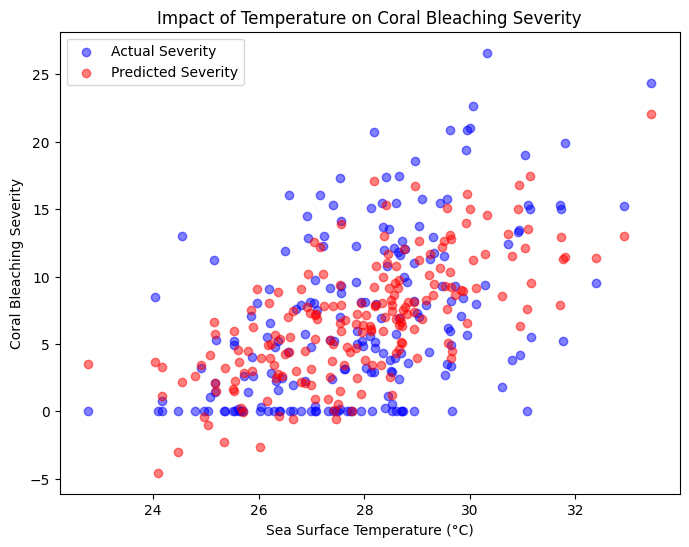

In [1]:
# ============================================================
# PASO 1: IMPORTACIONES Y DATOS — PREDICCIÓN DE BLANQUEAMIENTO CORAL
# ============================================================
# Este análisis modela la severidad de blanqueamiento de coral en función de:
#   - Temperatura (°C): temperaturas > 29°C causan estrés térmico en corales
#   - pH: acidificación oceánica debilita el esqueleto de carbonato
#   - Radiación UV: exposición excesiva daña el tejido fotosintético (zooxantelas)
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

# Semilla para reproducibilidad del experimento simulado
np.random.seed(42)
data_size = 200

# ============================================================
# PASO 2: GENERAR VARIABLES INDEPENDIENTES (PREDICTORES)
# ============================================================
# Las distribuciones normales simulan mediciones reales de campo con variabilidad natural.
temperature  = np.random.normal(28, 2, data_size)  # TSM promedio 28°C (zona tropical)
pH           = np.random.normal(8.1, 0.1, data_size) # pH ligeramente básico (condición normal marina)
uv_radiation = np.random.normal(5, 1, data_size)   # Índice UV 0-10 (5 = moderado)

# ============================================================
# PASO 3: GENERAR VARIABLE DEPENDIENTE (SEVERIDAD DE BLANQUEAMIENTO)
# ============================================================
# La ecuación de generación refleja relaciones conocidas en ecología marina:
#   - +2 * (temperatura - 26): severidad aumenta 2 unidades por grado sobre el umbral de 26°C
#   - -5 * (pH - 8): mayor acidificación (pH bajo) → mayor severidad de blanqueamiento
#   - +3 * (UV - 4): mayor radiación UV → mayor daño tisular
#   - np.random.normal(0, 5): término de error aleatorio (ruido ecológico no capturado)
bleaching_severity = (2 * (temperature - 26) +
                      -5 * (pH - 8) +
                       3 * (uv_radiation - 4) +
                       np.random.normal(0, 5, data_size))
# Limitar al rango físicamente posible [0, 100]
bleaching_severity = np.clip(bleaching_severity, 0, 100)

data = pd.DataFrame({
    'Temperature'             : temperature,
    'pH'                      : pH,
    'UV Radiation'            : uv_radiation,
    'Coral Bleaching Severity': bleaching_severity
})

# ============================================================
# PASO 4: AJUSTAR MODELO OLS
# ============================================================
# sm.add_constant() agrega una columna de 1s para que el modelo tenga intercepto β₀.
# sm.OLS(y, X).fit() minimiza la suma de cuadrados de los residuos (método de mínimos cuadrados).
X = data[['Temperature', 'pH', 'UV Radiation']]
X = sm.add_constant(X)  # Agrega β₀ (intercepto)
y = data['Coral Bleaching Severity']

model = sm.OLS(y, X).fit()

# ============================================================
# PASO 5: INTERPRETAR RESULTADOS
# ============================================================
# La tabla de resultados muestra para cada predictor:
#   - coef: el cambio esperado en Y por unidad de cambio en X (ceteris paribus)
#   - std err: error estándar del coeficiente (menor = más precisión)
#   - P>|t|: p-valor del test t; < 0.05 → predictor estadísticamente significativo
#   - R²: proporción de varianza de Y explicada por el modelo (0-1)
print("RESUMEN DEL MODELO DE REGRESIÓN MÚLTIPLE:")
print(model.summary())

# ============================================================
# PASO 6: VISUALIZAR PREDICCIONES VS VALORES REALES
# ============================================================
# Este gráfico compara los valores observados (azul) con las predicciones del modelo (rojo)
# en función de la temperatura. Una buena predicción los tendría superpuestos.
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(data['Temperature'], y,              color='steelblue', alpha=0.5, label='Severidad Observada', s=40)
ax.scatter(data['Temperature'], model.predict(X), color='coral',    alpha=0.5, label='Severidad Predicha',   s=40)
ax.set_xlabel('Temperatura Superficial del Mar (°C)')
ax.set_ylabel('Severidad de Blanqueamiento Coral (0-100)')
ax.set_title('Temperatura vs. Severidad de Blanqueamiento: Observado vs. Predicho', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# NOTA: El VIF (Factor de Inflación de la Varianza) para detectar multicolinealidad
# se calcula en la celda siguiente. VIF > 10 = multicolinealidad grave.
print()
print("GUÍA RÁPIDA — INTERPRETACIÓN DE R²:")
print(f"  R² = {model.rsquared:.4f} → el modelo explica {model.rsquared*100:.1f}% de la varianza en severidad")
print(f"  R² ajustado = {model.rsquared_adj:.4f} (penalizado por número de predictores)")


                               OLS Regression Results                               
Dep. Variable:     Coral Bleaching Severity   R-squared:                       0.017
Model:                                  OLS   Adj. R-squared:                  0.011
Method:                       Least Squares   F-statistic:                     2.885
Date:                      Mon, 06 Apr 2026   Prob (F-statistic):             0.0353
Time:                              17:08:50   Log-Likelihood:                -1816.3
No. Observations:                       500   AIC:                             3641.
Df Residuals:                           496   BIC:                             3658.
Df Model:                                 3                                         
Covariance Type:                  nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

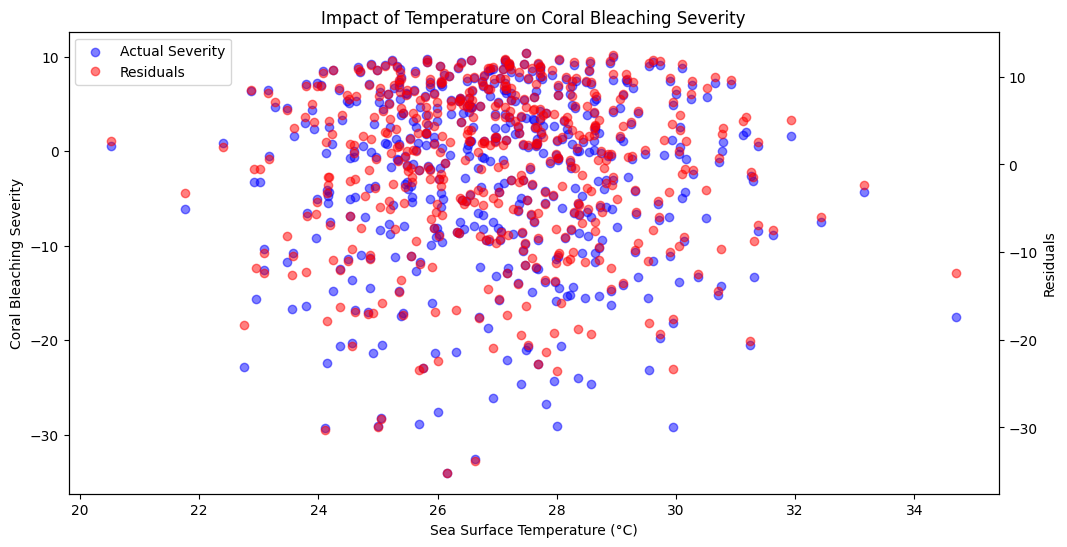

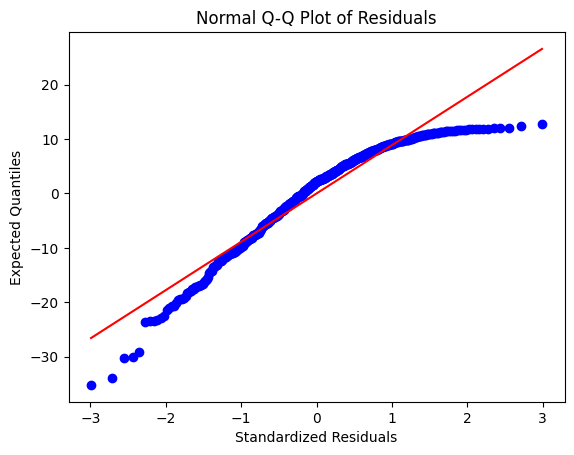

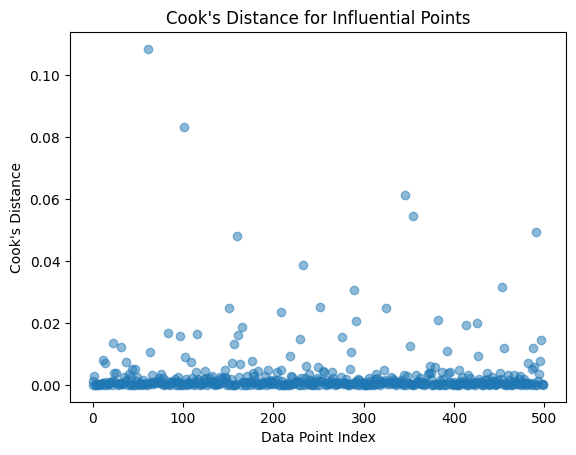

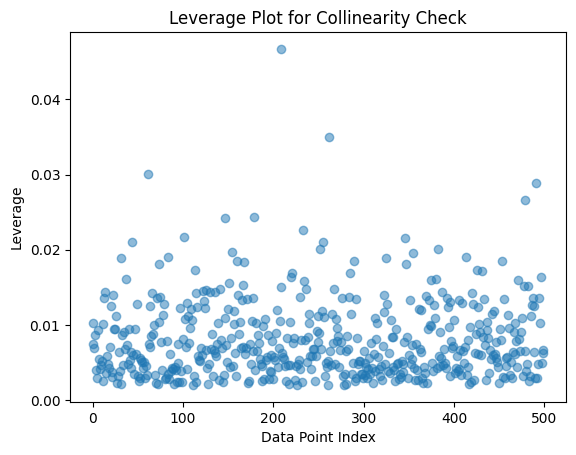

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy import stats

# Generate synthetic data
np.random.seed(42)
data_size = 500  # Increase sample size for better results

temperature = np.random.normal(27, 2, data_size)  # Average temp 27°C with some variation
pH = np.random.normal(8.1, 0.1, data_size)  # Slightly basic water
uv_radiation = np.random.normal(200, 50, data_size)  # Average UV radiation
bleaching_severity = 10 - (0.2 * abs(temperature - 27) + 0.1 * abs(pH - 8.1) + 0.3 * abs(uv_radiation - 200) + np.random.normal(0, 0.3, data_size))

data = pd.DataFrame({
    'Temperature': temperature,
    'pH': pH,
    'UV Radiation': uv_radiation,
    'Coral Bleaching Severity': bleaching_severity
})

# Building the multiple regression model
X = data[['Temperature', 'pH', 'UV Radiation']]
X = sm.add_constant(X)  # Adding a constant term for the intercept
y = data['Coral Bleaching Severity']

model = sm.OLS(y, X).fit()

# Display the regression results
print(model.summary())

# Residuals plot
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

ax1.scatter(data['Temperature'], y, color='blue', alpha = 0.5, label='Actual Severity')
ax2.plot(data['Temperature'], model.resid, color='red', alpha = 0.5, label='Residuals', linestyle='none', marker='o')

ax1.set_xlabel('Sea Surface Temperature (°C)')
ax1.set_ylabel('Coral Bleaching Severity')
ax2.set_ylabel('Residuals')
ax1.set_title('Impact of Temperature on Coral Bleaching Severity')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.show()

# QQ-Plot for normality check
fig, ax = plt.subplots()
stats.probplot(model.resid, plot = ax)
ax.set_xlabel('Standardized Residuals')
ax.set_ylabel('Expected Quantiles')
ax.set_title('Normal Q-Q Plot of Residuals')
plt.show()

# Cook's Distance for influential points
fig, ax = plt.subplots()
cooks_distance = model.get_influence().cooks_distance
plt.scatter(range(len(cooks_distance[0])), cooks_distance[0], alpha = 0.5)
plt.xlabel('Data Point Index')
plt.ylabel('Cook\'s Distance')
plt.title('Cook\'s Distance for Influential Points')
plt.show()

# Leverage plot for collinearity check
fig, ax = plt.subplots()
leverage = model.get_influence().hat_matrix_diag  # Remove the parentheses
plt.scatter(range(len(leverage)), leverage, alpha = 0.5)
plt.xlabel('Data Point Index')
plt.ylabel('Leverage')
plt.title('Leverage Plot for Collinearity Check')
plt.show()



# VIF (Variance Inflation Factor) Check for Multicollinearity:
# VIF < 5: Generally acceptable
# VIF 5-10: Moderate multicollinearity, consider removing variable
# VIF > 10: High multicollinearity, likely remove variable
# To calculate: from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
# ============================================================
# DIAGNÓSTICO DE MULTICOLINEALIDAD — FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)
# ============================================================
# La multicolinealidad ocurre cuando los predictores están fuertemente correlacionados entre sí.
# Consecuencias:
#   - Los coeficientes se vuelven inestables (cambian mucho con pequeñas variaciones en datos)
#   - Los errores estándar se inflan → los tests de hipótesis pierden poder
#   - El R² puede ser alto pero los coeficientes individuales son poco confiables
#
# VIF_j = 1/(1-R²_j) donde R²_j es el R² de la regresión de X_j sobre las demás variables.

from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# ============================================================
# PASO 1: CALCULAR VIF PARA CADA PREDICTOR
# ============================================================
# X debe incluir solo los predictores (sin el intercepto) para el cálculo correcto.
# variance_inflation_factor(X.values, i) calcula VIF para la columna i.
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns  # Nombres de las variables predictoras

# Se calcula VIF iterando por cada predictor en la matriz X
vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print("=" * 55)
print("FACTOR DE INFLACIÓN DE LA VARIANZA (VIF)")
print("=" * 55)
print(vif_data.to_string(index=False))
print()

# ============================================================
# PASO 2: INTERPRETAR RESULTADOS Y TOMAR DECISIÓN
# ============================================================
# Umbrales estándar (Field, 2013; Hair et al., 2014):
print("Guía de Interpretación del VIF:")
print("  VIF < 5    → Sin problemas de multicolinealidad (aceptable)")
print("  VIF 5-10   → Multicolinealidad moderada (monitorear)")
print("  VIF > 10   → Multicolinealidad grave (eliminar o combinar variable)")
print()

# Identificar automáticamente predictores problemáticos
problematic = vif_data[vif_data['VIF'] > 5]
if len(problematic) > 0:
    print("⚠ Variables con posible multicolinealidad (VIF > 5):")
    print(problematic.to_string(index=False))
    print()
    print("Acciones recomendadas:")
    print("  1. Eliminar el predictor con mayor VIF si aporta poca información única")
    print("  2. Combinar predictores correlacionados (e.g., índice compuesto)")
    print("  3. Usar regresión Ridge o Lasso que penalizan multicolinealidad")
else:
    print("✓ Sin problemas de multicolinealidad. Todos los VIF < 5.")
    print("  Los predictores son suficientemente independientes entre sí.")
    print("  Los coeficientes de regresión son estables e interpretables.")


Variance Inflation Factor (VIF) for Multicollinearity Check:
       Variable          VIF
0         const  7285.609525
1   Temperature     1.008522
2            pH     1.010999
3  UV Radiation     1.008578

VIF Interpretation Guide:
- VIF < 5: Generally acceptable (low multicollinearity)
- VIF 5-10: Moderate multicollinearity, consider removing variable
- VIF > 10: High multicollinearity, strongly consider removing variable

Variables with potential multicollinearity issues:
  Variable          VIF
0    const  7285.609525


# Ejercicios para el Estudiante

## Ejercicio 1: Predicción de Floración de Algas
Construye un modelo de regresión múltiple para predecir densidad de algas usando:
- Variables independientes: temperatura, nutrientes (N, P), salinidad, profundidad
- Estandariza todas las variables
- Calcula VIF para detectar multicolinealidad
- Interpreta coeficientes de regresión
- ¿Qué variables son más importantes?

## Ejercicio 2: Diagnóstico de Supuestos
Para tu modelo de regresión:
- Verifica linealidad con gráficos de dispersión residuales vs. predichos
- Evalúa normalidad de residuos con gráfico Q-Q
- Examina homocedasticidad
- Identifica y evalúa puntos influyentes (leverage, Cook's distance)
- Realiza transformaciones si es necesario

## Ejercicio 3: Selección de Variables
Con un conjunto expandido de posibles predictores:
- Usa regresión stepwise o selección hacia adelante/atrás
- Compara modelos usando AIC/BIC
- Valida el modelo final con datos de prueba
- Calcula R² ajustado y RMSE
- ¿Qué variables son realmente necesarias?